# 2. Glamsterdam metering multipliers

This notebook converts the February–May 2026 historical accounting anchor into counterfactual Glamsterdam gas. It calculates one total-ratio multiplier for each resource:

- execution under EIP-8038 and EIP-2780, including the reconstructed EIP-8038 refunds;
- data under the EIP-7976 floor and EIP-7981 access-list charge; and
- state under EIP-8037 with CPSB = 1530.

The multiplier is counterfactual Glamsterdam gas divided by historical gas-equivalent activity for the same 120-day sample. Notebook 01 must be run first.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
})


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root")


PROJECT_ROOT = find_project_root(Path.cwd())
OUT_DIR = PROJECT_ROOT / "data" / "glamsterdam"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

ANCHOR_PANEL = OUT_DIR / "anchor_accounting_panel_2026-02-01_2026-05-31.csv"
MULTIPLIER_OUT = OUT_DIR / "metering_multipliers.csv"
ANCHOR_OUT = OUT_DIR / "equilibrium_anchor.csv"
COMPONENT_OUT = OUT_DIR / "metering_accounting_components.csv"
PLOT_OUT = PLOTS_DIR / "execution_repricing_8038_2780_2026-02-01_2026-06-01.png"

if not ANCHOR_PANEL.exists():
    raise FileNotFoundError(f"Missing {ANCHOR_PANEL}. Run notebook 01 first.")

anchor = pd.read_csv(ANCHOR_PANEL)
anchor["date"] = pd.to_datetime(anchor["date"])
anchor.shape

(120, 31)

## Historical anchor and counterfactual totals

The historical execution denominator is total gas minus current data and calibrated state creation. A strict identity check ensures that it matches the denominator used by the execution-repricing export.

In [2]:
blocks = float(anchor["block_count"].sum())
base_fee_ref = float(anchor["median_base_fee_per_gas"].median())

historical_totals = {
    "execution": float(anchor["historical_execution_gas"].sum()),
    "data": float(anchor["data_gas_current"].sum()),
    "state": float(anchor["current_state_creation_gas_calibrated"].sum()),
}
counterfactual_totals = {
    "execution": float(anchor["execution_8038_2780_refund_corrected"].sum()),
    "data": float(anchor["data_gas_glamsterdam"].sum()),
    "state": float(anchor["state_gas_8037_calibrated"].sum()),
}
multipliers = {
    resource: counterfactual_totals[resource] / historical_totals[resource]
    for resource in historical_totals
}

assert len(anchor) == 120
assert np.allclose(
    anchor["execution_current"].sum(),
    historical_totals["execution"],
    rtol=1e-10,
    atol=1,
)
assert all(value > 1 for value in multipliers.values())

total_historical = sum(historical_totals.values())
multiplier_table = pd.DataFrame([
    {
        "resource": resource,
        "historical_gas_per_block": historical_totals[resource] / blocks,
        "glamsterdam_gas_per_block": counterfactual_totals[resource] / blocks,
        "multiplier": multipliers[resource],
        "historical_share": historical_totals[resource] / total_historical,
    }
    for resource in ["execution", "data", "state"]
])
multiplier_table.to_csv(MULTIPLIER_OUT, index=False)
multiplier_table

,resource,historical_gas_per_block,glamsterdam_gas_per_block,multiplier,historical_share
0,execution,"23,942,241.363434","36,820,725.629258",1.537898,0.788431
1,data,"1,180,555.063055","2,324,231.531878",1.968762,0.038876
2,state,"5,244,154.703798","29,662,592.274090",5.656315,0.172693


In [3]:
equilibrium_anchor = pd.DataFrame([{
    "start_date": anchor["date"].min().date().isoformat(),
    "end_date_inclusive": anchor["date"].max().date().isoformat(),
    "days": len(anchor),
    "blocks": int(blocks),
    "base_fee_ref_wei": base_fee_ref,
    "base_fee_ref_gwei": base_fee_ref / 1e9,
    **{
        f"q_{resource}_per_block": historical_totals[resource] / blocks
        for resource in ["execution", "data", "state"]
    },
    **{
        f"m_{resource}": multipliers[resource]
        for resource in ["execution", "data", "state"]
    },
}])
equilibrium_anchor.to_csv(ANCHOR_OUT, index=False)
equilibrium_anchor.T

,0
start_date,2026-02-01
end_date_inclusive,2026-05-31
days,120
blocks,860505
base_fee_ref_wei,"106,927,843.500000"
base_fee_ref_gwei,0.106928
q_execution_per_block,"23,942,241.363434"
q_data_per_block,"1,180,555.063055"
q_state_per_block,"5,244,154.703798"
m_execution,1.537898


## Accounting decomposition

These rows reproduce the execution, data, and state accounting tables in the report. “Other EIP-8038 changes” is the central EIP-8038 delta net of SSTORE and cold-SLOAD changes.

In [4]:
execution_before_refunds = float(anchor["execution_8038_2780"].sum())
execution_after_refunds = counterfactual_totals["execution"]

components = pd.DataFrame([
    {"resource": "execution", "component": "Historical regular execution gas",
     "gas_per_block": historical_totals["execution"] / blocks},
    {"resource": "execution", "component": "EIP-8038 SSTORE increase",
     "gas_per_block": anchor["delta_8038_sstore"].sum() / blocks},
    {"resource": "execution", "component": "EIP-8038 cold SLOAD increase",
     "gas_per_block": anchor["delta_8038_sload_cold"].sum() / blocks},
    {"resource": "execution", "component": "Other EIP-8038 changes",
     "gas_per_block": (
         anchor["delta_8038_central"]
         - anchor["delta_8038_sstore"]
         - anchor["delta_8038_sload_cold"]
     ).sum() / blocks},
    {"resource": "execution", "component": "EIP-2780 intrinsic-gas changes",
     "gas_per_block": anchor["delta_2780_intrinsic"].sum() / blocks},
    {"resource": "execution", "component": "Counterfactual gas before new refunds",
     "gas_per_block": execution_before_refunds / blocks},
    {"resource": "execution", "component": "Additional effective EIP-8038 refunds",
     "gas_per_block": (execution_after_refunds - execution_before_refunds) / blocks},
    {"resource": "execution", "component": "Counterfactual execution gas after refunds",
     "gas_per_block": execution_after_refunds / blocks},
    {"resource": "data", "component": "Historical data gas",
     "gas_per_block": historical_totals["data"] / blocks},
    {"resource": "data", "component": "EIP-7976 floor uplift",
     "gas_per_block": anchor["eip7976_floor_uplift_current_body"].sum() / blocks},
    {"resource": "data", "component": "Calibrated EIP-7981 access-list gas",
     "gas_per_block": anchor["eip7981_access_list_data_gas_calibrated"].sum() / blocks},
    {"resource": "data", "component": "Glamsterdam counterfactual data gas",
     "gas_per_block": counterfactual_totals["data"] / blocks},
    {"resource": "state", "component": "Historical gas-equivalent proxy",
     "gas_per_block": historical_totals["state"] / blocks},
    {"resource": "state", "component": "EIP-8037 state gas",
     "gas_per_block": counterfactual_totals["state"] / blocks},
])
components.to_csv(COMPONENT_OUT, index=False)
components.assign(gas_per_block_M=components["gas_per_block"] / 1e6)

,resource,component,gas_per_block,gas_per_block_M
0,execution,Historical regular execution gas,"23,942,241.363434",23.942241
1,execution,EIP-8038 SSTORE increase,"11,686,998.545684",11.686999
2,execution,EIP-8038 cold SLOAD increase,"2,081,631.322189",2.081631
3,execution,Other EIP-8038 changes,"634,737.198290",0.634737
4,execution,EIP-2780 intrinsic-gas changes,"-1,033,307.133021",-1.033307
5,execution,Counterfactual gas before new refunds,"37,312,301.296576",37.312301
6,execution,Additional effective EIP-8038 refunds,"-491,575.667318",-0.491576
7,execution,Counterfactual execution gas after refunds,"36,820,725.629258",36.820726
8,data,Historical data gas,"1,180,555.063055",1.180555
9,data,EIP-7976 floor uplift,"775,981.019879",0.775981


## Execution-repricing figure

The left panel decomposes the observed-path execution-gas changes. The right panel shows the daily multiplier and its pooled 120-day value.

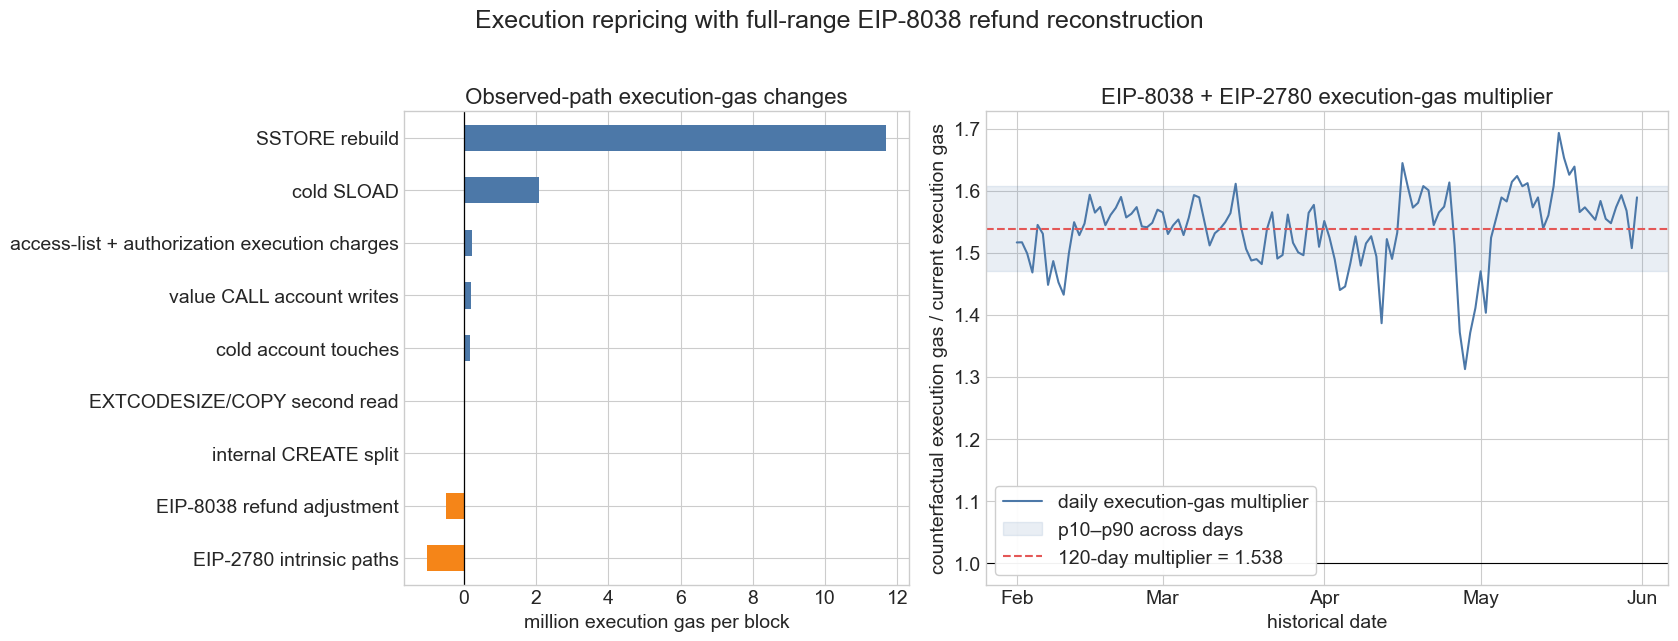

Wrote plots/execution_repricing_8038_2780_2026-02-01_2026-06-01.png


In [5]:
component_totals = pd.Series({
    "SSTORE rebuild": anchor["delta_8038_sstore"].sum(),
    "cold SLOAD": anchor["delta_8038_sload_cold"].sum(),
    "cold account touches": anchor["delta_8038_account_cold"].sum(),
    "EXTCODESIZE/COPY second read": anchor["delta_8038_ext_second_read"].sum(),
    "value CALL account writes": anchor["delta_8038_internal_value_calls"].sum(),
    "access-list + authorization execution charges": (
        anchor["delta_8038_access_lists"].sum()
        + anchor["delta_8038_authorizations"].sum()
    ),
    "internal CREATE split": anchor["delta_8038_internal_create"].sum(),
    "EIP-2780 intrinsic paths": anchor["delta_2780_intrinsic"].sum(),
    "EIP-8038 refund adjustment": -anchor["refund_extra_8038"].sum(),
})
component_per_block = component_totals / blocks

fig, axes = plt.subplots(
    1, 2, figsize=(17, 6.3), gridspec_kw={"width_ratios": [1.0, 1.35]}
)

ordered = (component_per_block / 1e6).sort_values()
colors = ["#4c78a8" if value >= 0 else "#f58518" for value in ordered]
ordered.plot.barh(ax=axes[0], color=colors)
axes[0].axvline(0, color="black", linewidth=0.9)
axes[0].set_title("Observed-path execution-gas changes")
axes[0].set_xlabel("million execution gas per block")
axes[0].set_ylabel("")

plot_daily = anchor.sort_values("date")
daily_multiplier = plot_daily["m_execution_8038_2780_refund_corrected_daily"]
p10, p90 = daily_multiplier.quantile([0.10, 0.90])
axes[1].plot(
    plot_daily["date"],
    daily_multiplier,
    color="#4c78a8",
    linewidth=1.5,
    label="daily execution-gas multiplier",
)
axes[1].axhspan(p10, p90, color="#4c78a8", alpha=0.12, label="p10–p90 across days")
axes[1].axhline(
    multipliers["execution"],
    color="#e45756",
    linestyle="--",
    linewidth=1.5,
    label=f"120-day multiplier = {multipliers['execution']:.3f}",
)
axes[1].axhline(1, color="black", linewidth=0.8)
axes[1].set_title("EIP-8038 + EIP-2780 execution-gas multiplier")
axes[1].set_ylabel("counterfactual execution gas / current execution gas")
axes[1].set_xlabel("historical date")
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[1].legend(loc="lower left", frameon=True, framealpha=0.95)

fig.suptitle(
    "Execution repricing with full-range EIP-8038 refund reconstruction",
    y=1.02,
    fontsize=18,
)
fig.tight_layout()
fig.savefig(PLOT_OUT, dpi=180, bbox_inches="tight")
plt.show()

print(f"Wrote {PLOT_OUT.relative_to(PROJECT_ROOT)}")

## Validation and handoff

Notebook 04 reads `equilibrium_anchor.csv`. The numerical checks below guard the rounded values reported in the manuscript without using those rounded values as inputs.

In [6]:
expected = {"execution": 1.5379, "data": 1.9688, "state": 5.6563}
for resource, target in expected.items():
    assert np.isclose(multipliers[resource], target, atol=5e-5), (
        resource,
        multipliers[resource],
        target,
    )

transaction_identification_share = (
    anchor["refund_txs_identified"].sum() / anchor["refund_txs_total"].sum()
)
refund_counter_identification_share = (
    anchor["refund_counter_identified"].sum() / anchor["refund_counter_total"].sum()
)
assert transaction_identification_share > 0.99
assert refund_counter_identification_share > 0.99

pd.DataFrame([{
    "transaction_identification_share": transaction_identification_share,
    "refund_counter_identification_share": refund_counter_identification_share,
    "multipliers_file": str(MULTIPLIER_OUT.relative_to(PROJECT_ROOT)),
    "anchor_file": str(ANCHOR_OUT.relative_to(PROJECT_ROOT)),
}])

,transaction_identification_share,refund_counter_identification_share,multipliers_file,anchor_file
0,0.997827,0.998208,data/glamsterdam/metering_multipliers.csv,data/glamsterdam/equilibrium_anchor.csv
